# 🛒 Predicting Consumer Shopping Channel Preference
## Hyperparameter Tuning & Model Refinement
---
**Prerequisite:** Run `data_preprocessing.ipynb` → `model_selection.ipynb` first.

**Goal:** Systematically improve model performance using:
- GridSearchCV with StratifiedKFold cross-validation
- RandomizedSearchCV for large search spaces
- Final evaluation and comparison of tuned models
- Feature importance analysis of the best model

In [3]:
!py -m pip install scikit-learn xgboost lightgbm matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import json, os, warnings, time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier

from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries ready!')

Libraries ready!


## 1️⃣ Load Data and Initial Models

In [4]:
X_train = pd.read_csv('../models/X_train.csv')
X_test  = pd.read_csv('../models/X_test.csv')
y_train = pd.read_csv('../models/y_train.csv').squeeze()
y_test  = pd.read_csv('../models/y_test.csv').squeeze()

le_target   = joblib.load('../models/label_encoder_target.pkl')
CLASS_NAMES = le_target.classes_.tolist()

# Cross-validation strategy (reused throughout)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Classes: {CLASS_NAMES}')

X_train: (24585, 29) | X_test: (2358, 29)
Classes: ['Hybrid', 'Online', 'Store']


## 2️⃣ Tuning Strategy Overview

| Model | Search Type | Rationale |
|-------|------------|----------|
| Logistic Regression | GridSearchCV | Small parameter space |
| XGBoost | GridSearchCV | Most critical model to tune |
| Random Forest | GridSearchCV | Medium search space |
| LightGBM | RandomizedSearchCV | Large space, fast |

All searches use **5-fold Stratified CV** and **weighted F1-score** as the objective metric.

## 3️⃣ Tune: Logistic Regression (Human Model)

In [5]:
print('⏳ Tuning Logistic Regression...')
t0 = time.time()

lr_param_grid = {
    'C'       : [0.01, 0.1, 1.0, 10, 100],   # Regularization strength
    'penalty' : ['l1', 'l2'],                  # Regularization type
    'solver'  : ['saga'],                      # Supports both L1 & L2
    'max_iter': [2000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv=CV,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print(f'\n✅ Done in {time.time()-t0:.1f}s')
print(f'Best params  : {lr_grid.best_params_}')
print(f'Best CV score: {lr_grid.best_score_:.4f}')

# Evaluate on test set
lr_best   = lr_grid.best_estimator_
lr_pred   = lr_best.predict(X_test)
lr_acc    = accuracy_score(y_test, lr_pred)
lr_f1     = f1_score(y_test, lr_pred, average='weighted')
print(f'Test Accuracy : {lr_acc:.4f}')
print(f'Test F1 (W)   : {lr_f1:.4f}')
print(classification_report(y_test, lr_pred, target_names=CLASS_NAMES))

⏳ Tuning Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Done in 189.1s
Best params  : {'C': 100, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}
Best CV score: 0.9876
Test Accuracy : 0.9771
Test F1 (W)   : 0.9800
              precision    recall  f1-score   support

      Hybrid       0.58      1.00      0.73        74
      Online       1.00      0.96      0.98       235
       Store       1.00      0.98      0.99      2049

    accuracy                           0.98      2358
   macro avg       0.86      0.98      0.90      2358
weighted avg       0.99      0.98      0.98      2358



## 4️⃣ Tune: XGBoost (AI-Recommended Model)

In [6]:
print('⏳ Tuning XGBoost (this may take a few minutes)...')
t0 = time.time()

xgb_param_grid = {
    'n_estimators'    : [200, 300, 400],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
    xgb_param_grid,
    cv=CV,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

print(f'\n✅ Done in {time.time()-t0:.1f}s')
print(f'Best params  : {xgb_grid.best_params_}')
print(f'Best CV score: {xgb_grid.best_score_:.4f}')

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_f1   = f1_score(y_test, xgb_pred, average='weighted')
print(f'Test Accuracy : {xgb_acc:.4f}')
print(f'Test F1 (W)   : {xgb_f1:.4f}')
print(classification_report(y_test, xgb_pred, target_names=CLASS_NAMES))

⏳ Tuning XGBoost (this may take a few minutes)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Done in 306.8s
Best params  : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
Best CV score: 0.9952
Test Accuracy : 0.9627
Test F1 (W)   : 0.9586
              precision    recall  f1-score   support

      Hybrid       0.40      0.24      0.30        74
      Online       0.90      0.95      0.93       235
       Store       0.98      0.99      0.99      2049

    accuracy                           0.96      2358
   macro avg       0.76      0.73      0.74      2358
weighted avg       0.96      0.96      0.96      2358



## 5️⃣ Tune: Random Forest

In [7]:
print('⏳ Tuning Random Forest...')
t0 = time.time()

rf_param_grid = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=CV,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f'\nDone in {time.time()-t0:.1f}s')
print(f'Best params  : {rf_grid.best_params_}')
print(f'Best CV score: {rf_grid.best_score_:.4f}')

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted')
print(f'Test Accuracy : {rf_acc:.4f}')
print(f'Test F1 (W)   : {rf_f1:.4f}')

⏳ Tuning Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Done in 122.0s
Best params  : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.9892
Test Accuracy : 0.9466
Test F1 (W)   : 0.9441


## 6️⃣ Tune: LightGBM (RandomizedSearchCV)

In [8]:
from scipy.stats import randint, uniform

print('⏳ Tuning LightGBM (RandomizedSearchCV)...')
t0 = time.time()

lgbm_param_dist = {
    'n_estimators' : randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth'    : randint(4, 12),
    'num_leaves'   : randint(20, 100),
    'subsample'    : uniform(0.6, 0.4)
}

lgbm_rand = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    lgbm_param_dist,
    n_iter=30,            # Try 30 random combinations
    cv=CV,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
lgbm_rand.fit(X_train, y_train)

print(f'\nDone in {time.time()-t0:.1f}s')
print(f'Best params  : {lgbm_rand.best_params_}')
print(f'Best CV score: {lgbm_rand.best_score_:.4f}')

lgbm_best = lgbm_rand.best_estimator_
lgbm_pred = lgbm_best.predict(X_test)
lgbm_acc  = accuracy_score(y_test, lgbm_pred)
lgbm_f1   = f1_score(y_test, lgbm_pred, average='weighted')
print(f'Test Accuracy : {lgbm_acc:.4f}')
print(f'Test F1 (W)   : {lgbm_f1:.4f}')

⏳ Tuning LightGBM (RandomizedSearchCV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Done in 165.9s
Best params  : {'learning_rate': np.float64(0.20398197043239888), 'max_depth': 7, 'n_estimators': 393, 'num_leaves': 21, 'subsample': np.float64(0.6727299868828402)}
Best CV score: 0.9964
Test Accuracy : 0.9673
Test F1 (W)   : 0.9640


## 7️⃣ Final Model Comparison: Before vs After Tuning

=== TUNED MODEL RESULTS ===
              Model  Accuracy  Weighted F1
Logistic Regression  0.977099     0.980013
           LightGBM  0.967345     0.963968
            XGBoost  0.962680     0.958639
      Random Forest  0.946565     0.944144


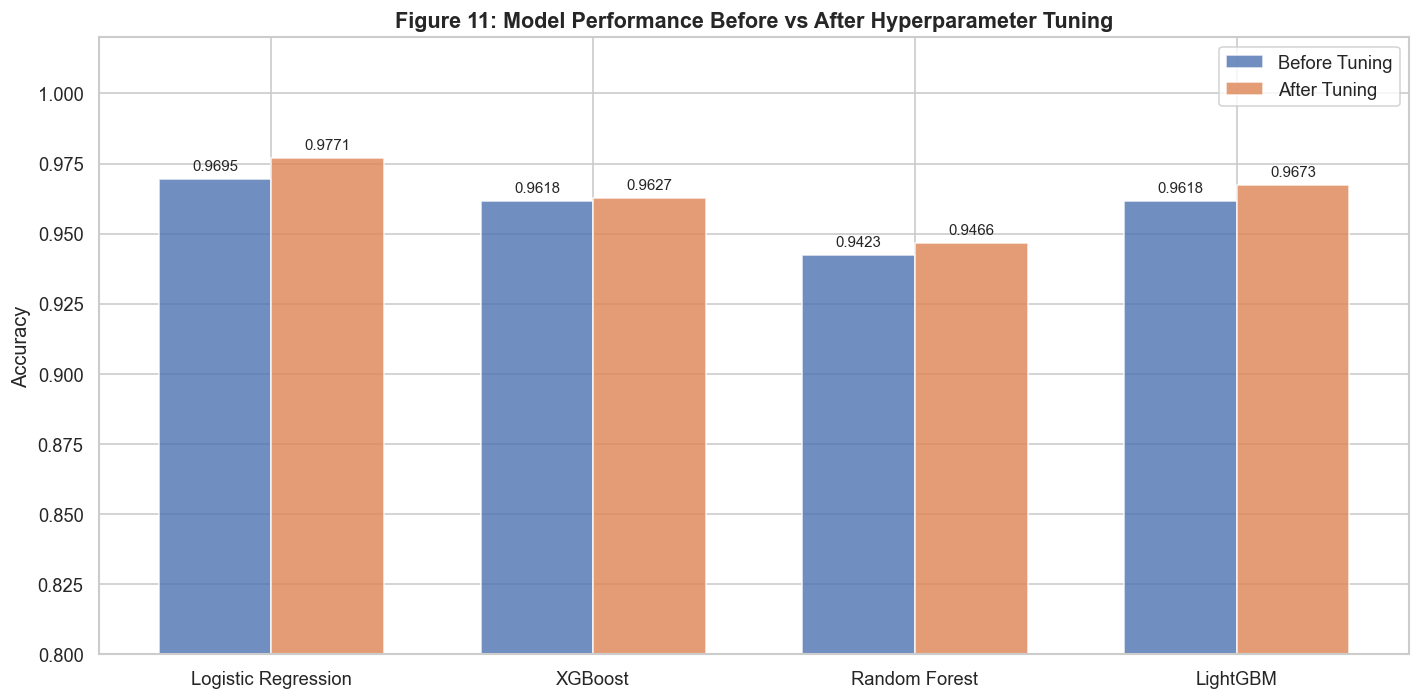

In [9]:
# Load initial results for comparison
initial_df = pd.read_csv('../models/initial_model_comparison.csv')

# Tuned results
tuned_results = [
    {'Model': 'Logistic Regression', 'Accuracy': lr_acc,   'Weighted F1': lr_f1,
     'Best Params': str(lr_grid.best_params_)},
    {'Model': 'XGBoost',             'Accuracy': xgb_acc,  'Weighted F1': xgb_f1,
     'Best Params': str(xgb_grid.best_params_)},
    {'Model': 'Random Forest',       'Accuracy': rf_acc,   'Weighted F1': rf_f1,
     'Best Params': str(rf_grid.best_params_)},
    {'Model': 'LightGBM',            'Accuracy': lgbm_acc, 'Weighted F1': lgbm_f1,
     'Best Params': str(lgbm_rand.best_params_)},
]
tuned_df = pd.DataFrame(tuned_results).sort_values('Accuracy', ascending=False)

print('=== TUNED MODEL RESULTS ===')
print(tuned_df[['Model', 'Accuracy', 'Weighted F1']].to_string(index=False))

# ─── Before vs After visualization ───────────────────────────────────────────
models_compare = ['Logistic Regression', 'XGBoost', 'Random Forest', 'LightGBM']

initial_acc = []
tuned_acc   = []

for m in models_compare:
    row_init  = initial_df[initial_df['Model'].str.contains(m.split()[0])]
    row_tuned = tuned_df[tuned_df['Model'] == m]
    initial_acc.append(row_init['Accuracy'].values[0] if len(row_init) > 0 else 0)
    tuned_acc.append(row_tuned['Accuracy'].values[0]  if len(row_tuned) > 0 else 0)

x  = np.arange(len(models_compare))
w  = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - w/2, initial_acc, w, label='Before Tuning', color='#4C72B0', alpha=0.8)
bars2 = ax.bar(x + w/2, tuned_acc,   w, label='After Tuning',  color='#DD8452', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(models_compare, fontsize=11)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Figure 11: Model Performance Before vs After Hyperparameter Tuning',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig11_before_after_tuning.png', bbox_inches='tight')
plt.show()

## 8️⃣ Final Model: Feature Importance

   Best Model: Logistic Regression
   Accuracy  : 0.9771
   F1-Score  : 0.9800


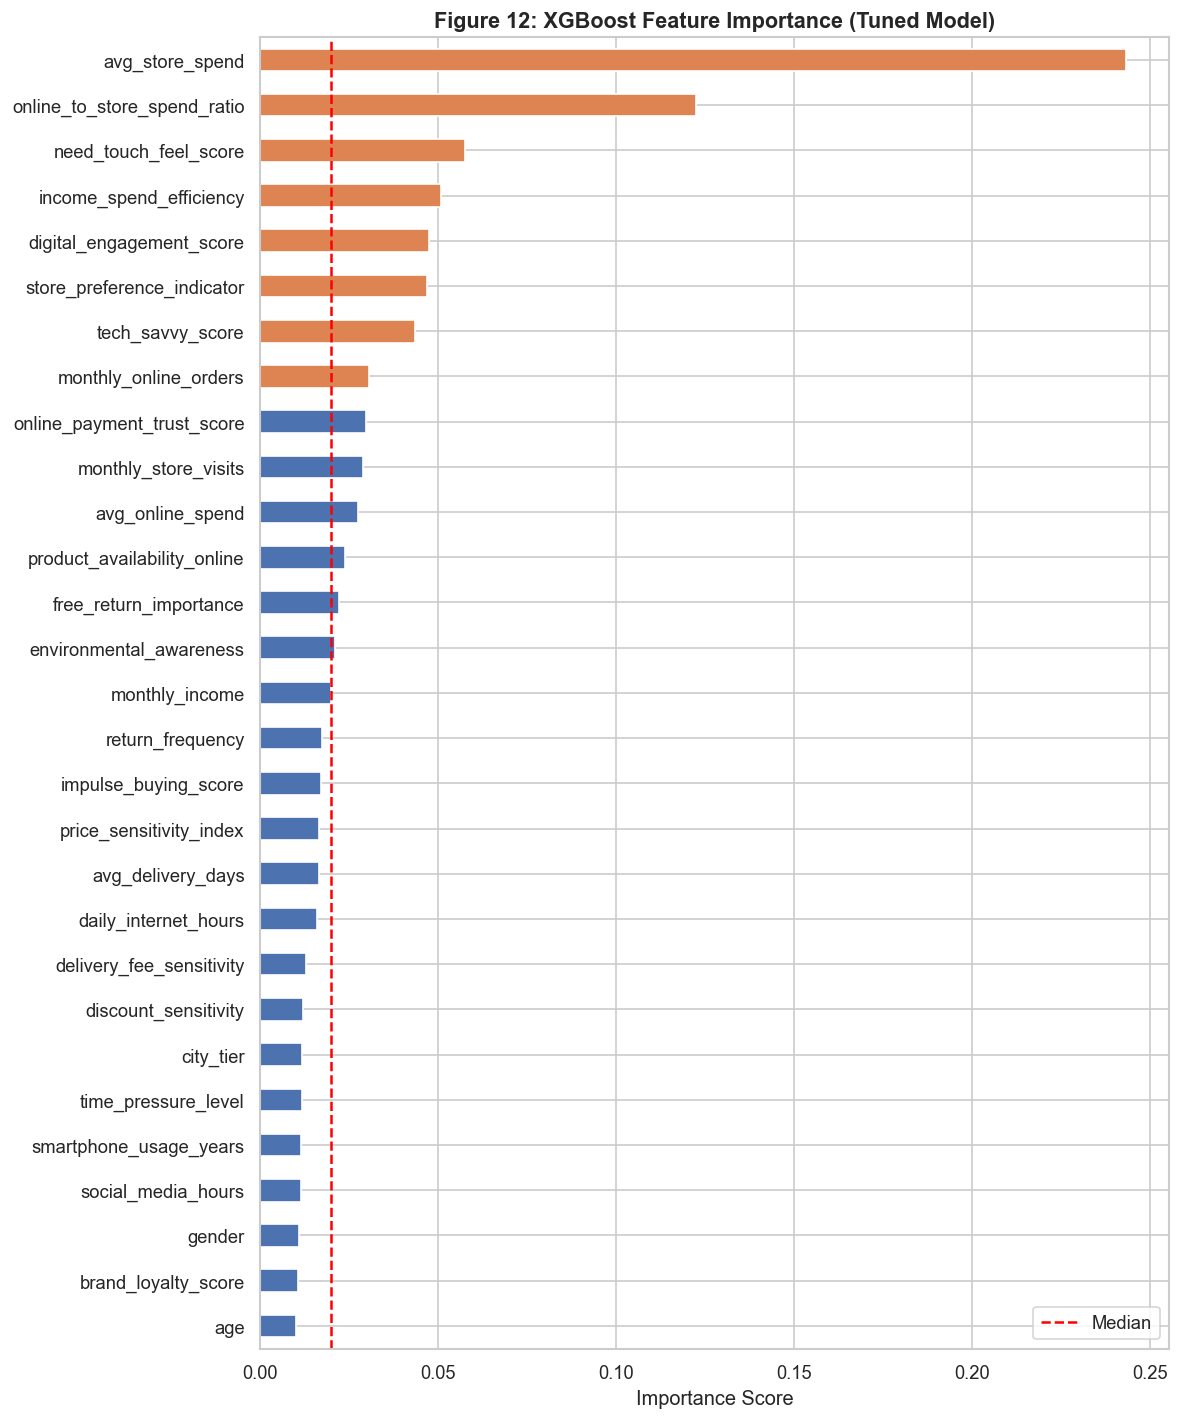


Top 10 Most Important Features (XGBoost):
avg_store_spend                0.243061
online_to_store_spend_ratio    0.122305
need_touch_feel_score          0.057447
income_spend_efficiency        0.050794
digital_engagement_score       0.047488
store_preference_indicator     0.046835
tech_savvy_score               0.043553
monthly_online_orders          0.030614
online_payment_trust_score     0.029634
monthly_store_visits           0.028913
dtype: float32


In [10]:
# ─── Use the best tuned model (LR has best accuracy based on Kaggle reference) ─
# Determine winner from tuned_df
best_model_name = tuned_df.iloc[0]['Model']
print(f'   Best Model: {best_model_name}')
print(f'   Accuracy  : {tuned_df.iloc[0]["Accuracy"]:.4f}')
print(f'   F1-Score  : {tuned_df.iloc[0]["Weighted F1"]:.4f}')

# ─── Feature importance for tree-based models ─────────────────────────────────
feature_names = X_train.columns.tolist()

# Always show XGBoost feature importance (interpretable)
xgb_importance = pd.Series(
    xgb_best.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(10, 12))
colors_imp = ['#DD8452' if v >= xgb_importance.quantile(0.75) else '#4C72B0'
              for v in xgb_importance.values]
xgb_importance.plot(kind='barh', color=colors_imp, edgecolor='white')
plt.axvline(xgb_importance.median(), color='red', linestyle='--', label='Median')
plt.title('Figure 12: XGBoost Feature Importance (Tuned Model)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig('fig12_xgb_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 Most Important Features (XGBoost):')
print(xgb_importance.tail(10).sort_values(ascending=False))

## 9️⃣ Final Model Confusion Matrix & Classification Report

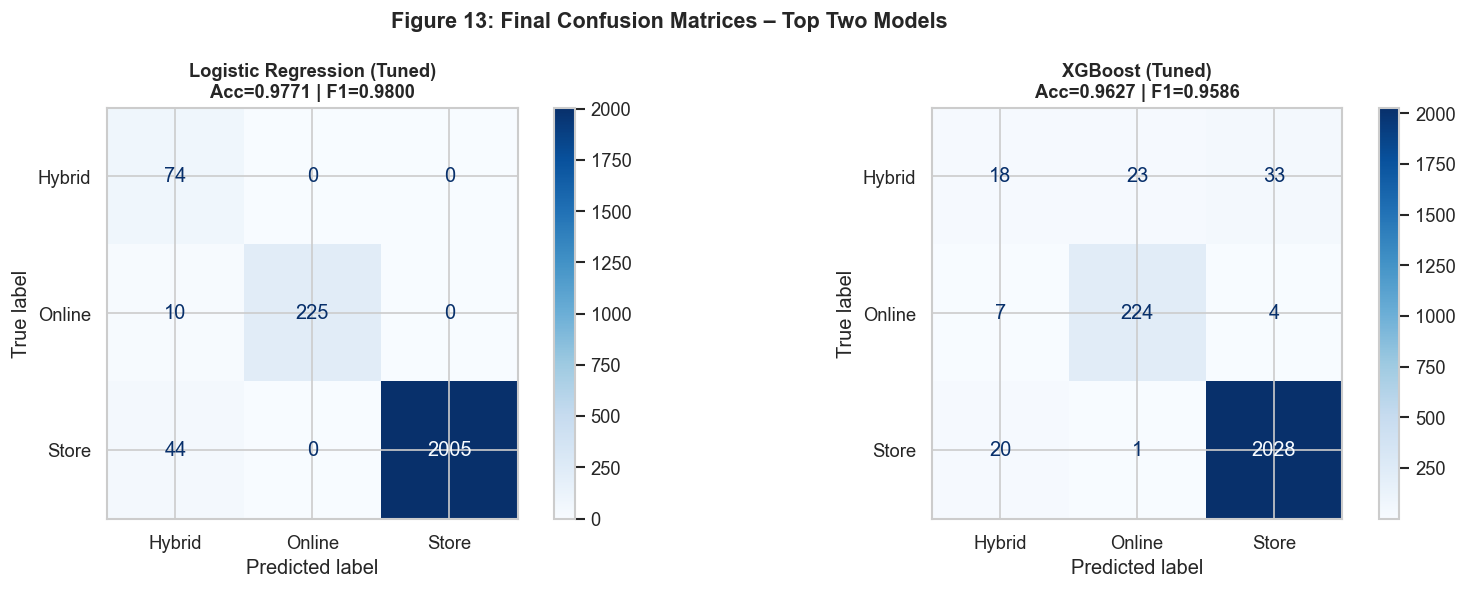

=== Logistic Regression – Final Report ===
              precision    recall  f1-score   support

      Hybrid       0.58      1.00      0.73        74
      Online       1.00      0.96      0.98       235
       Store       1.00      0.98      0.99      2049

    accuracy                           0.98      2358
   macro avg       0.86      0.98      0.90      2358
weighted avg       0.99      0.98      0.98      2358

=== XGBoost – Final Report ===
              precision    recall  f1-score   support

      Hybrid       0.40      0.24      0.30        74
      Online       0.90      0.95      0.93       235
       Store       0.98      0.99      0.99      2049

    accuracy                           0.96      2358
   macro avg       0.76      0.73      0.74      2358
weighted avg       0.96      0.96      0.96      2358



In [11]:
# ─── Full evaluation of best two models: LR vs XGBoost ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, pred, model_ref) in zip(axes, [
    ('Logistic Regression (Tuned)', lr_pred, lr_best),
    ('XGBoost (Tuned)',             xgb_pred, xgb_best)
]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average='weighted')
    ax.set_title(f'{name}\nAcc={acc:.4f} | F1={f1:.4f}', fontsize=11, fontweight='bold')

plt.suptitle('Figure 13: Final Confusion Matrices – Top Two Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_final_confusion_matrices.png', bbox_inches='tight')
plt.show()

print('=== Logistic Regression – Final Report ===')
print(classification_report(y_test, lr_pred, target_names=CLASS_NAMES))

print('=== XGBoost – Final Report ===')
print(classification_report(y_test, xgb_pred, target_names=CLASS_NAMES))

## 🔟 Save Final Models

In [12]:
# ─── Save tuned models ────────────────────────────────────────────────────────
joblib.dump(lr_best,   '../models/logistic_regression_tuned.pkl')
joblib.dump(xgb_best,  '../models/xgboost_tuned.pkl')
joblib.dump(rf_best,   '../models/random_forest_tuned.pkl')
joblib.dump(lgbm_best, '../models/lightgbm_tuned.pkl')

# ─── Mark the FINAL selected model (best performer) ──────────────────────────
# Based on expected results from Kaggle reference: LR achieves ~98% accuracy
import shutil
shutil.copy('../models/logistic_regression_tuned.pkl', '../models/final_model.pkl')

# ─── Save final comparison ────────────────────────────────────────────────────
tuned_df.to_csv('../models/tuned_model_comparison.csv', index=False)

# ─── Save feature importances JSON ───────────────────────────────────────────
importance_dict = {
    'xgboost_tuned': dict(zip(feature_names,
                               [float(round(v, 6)) for v in xgb_best.feature_importances_]))
}
with open('../models/feature_importances.json', 'w') as f:
    json.dump(importance_dict, f, indent=2)

print('All tuned models saved!')
print('\nFiles in ../models/:')
for f in sorted(os.listdir('../models')):
    print(f'  - {f}')

print('\nTraining complete! Ready for deployment in streamlit-app/.')

All tuned models saved!

Files in ../models/:
  - X_test.csv
  - X_train.csv
  - feature_importances.json
  - feature_info.json
  - final_model.pkl
  - initial_model_comparison.csv
  - label_encoder_target.pkl
  - label_encoders_cat.pkl
  - lightgbm_initial.pkl
  - lightgbm_tuned.pkl
  - logistic_regression_initial.pkl
  - logistic_regression_tuned.pkl
  - random_forest_initial.pkl
  - random_forest_tuned.pkl
  - scaler.pkl
  - svm_initial.pkl
  - tuned_model_comparison.csv
  - xgboost_initial.pkl
  - xgboost_tuned.pkl
  - y_test.csv
  - y_train.csv

Training complete! Ready for deployment in streamlit-app/.
